# The MLE case summer vs annual mean fields

In [1]:
%load_ext autoreload
%autoreload 2

import os
import x4c  # https://ncar.github.io/x4c/
import xarray as xr
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
print(x4c.__version__)
os.chdir('/glade/work/fengzhu/Projects/paper-MCO_iCESM/notebooks')

2026.5.26


## Get the MLE case

In [2]:
df_CO2pdf = pd.read_csv('../data/df_CO2pdf.csv', index_col=0)
idx = np.argmax(df_CO2pdf['density'])
print(idx)
print(df_CO2pdf.loc[idx])

305
CO2        2.291330
density    3.605485
dBWT       5.769833
dGMST      7.507091
dGMSST     6.197228
Name: 305, dtype: float64


In [4]:
case = {}

dirpath = '/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005'
case['1.5x'] = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'}, cesm_ver=1)

dirpath = '/glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005'
case['3x'] = x4c.Timeseries(dirpath, grid_dict={'atm': 'ne16np4'}, cesm_ver=1)

>>> case.root_dir: /glade/campaign/univ/ubrn0018/fengzhu/CESM_output/timeseries/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.1.5xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["ocn"]["pop.h.nday1"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["rof"]["rtm.h0"] created
>>> case.paths["rof"]["mosart.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["ocn"]["pop.h.nday1"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["rof"]["rtm.h0"] created
>>> case.vns["rof"]["mosart.h0"] created
>>> case.vns["ice"]["cice.h"] created
>>> case.root_dir: /glade/campaign/uni

In [5]:
SST = {}
SST['1.5x'] = case['1.5x'].calc('TEMP:ann', timespan=(4951, 5000), recalculate=True).isel(z_t=0).mean('time').x.regrid()
SST['3x'] = case['3x'].calc('SST:ann').mean('time').x.regrid()

SST_JJA = {}
SST_JJA['1.5x'] = case['1.5x'].calc('TEMP:6,7,8', timespan=(4951, 5000), recalculate=True).isel(z_t=0).mean('time').x.regrid()
SST_JJA['3x'] = case['3x'].calc('SST:6,7,8').mean('time').x.regrid()


>>> case.ds["TEMP"] created
>>> Timespan: [4951-01-01 00:00:00, 5000-12-01 00:00:00]
>>> case.diags["TEMP:ann"] created
>>> SST is a supported derived variable.
>>> case.ds["TEMP"] created
>>> case.ds["SST"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["SST:ann"] created
>>> case.ds["TEMP"] already loaded; to reload, run case.load("TEMP", ..., reload=True).
>>> Timespan: [4951-01-01 00:00:00, 5000-12-01 00:00:00]
>>> case.diags["TEMP:6,7,8"] created
>>> SST is a supported derived variable.
>>> case.ds["TEMP"] already loaded; to reload, run case.load("TEMP", ..., reload=True).
>>> case.ds["SST"] created
>>> Timespan: [8951-01-01 00:00:00, 9000-12-01 00:00:00]
>>> case.diags["SST:6,7,8"] created


In [6]:
# extrpolate to get 6x
SST['6x'] = SST['3x'] + (SST['3x'] - SST['1.5x'])
SST_JJA['6x'] = SST_JJA['3x'] + (SST_JJA['3x'] - SST_JJA['1.5x'])

In [9]:
SST_interp = np.linspace(SST['1.5x'].values, SST['6x'].values, len(df_CO2pdf))
SST_JJA_interp = np.linspace(SST_JJA['1.5x'].values, SST_JJA['6x'].values, len(df_CO2pdf))

In [10]:
SST['mle'] = SST['3x'].copy()
SST['mle'].values = SST_interp[idx]
SST_JJA['mle'] = SST_JJA['3x'].copy()
SST_JJA['mle'].values = SST_JJA_interp[idx]

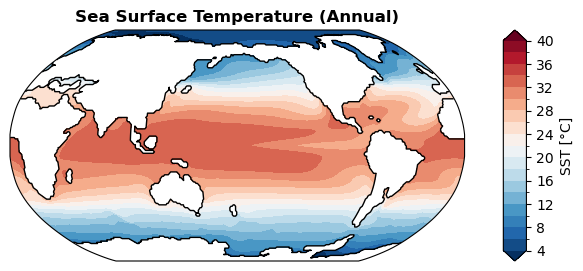

In [11]:
fig, ax = SST['mle'].x.plot(
    levels=np.linspace(4, 40, 19),
    cbar_kwargs={
        'ticks': np.linspace(4, 40, 10),
        'label': 'SST [°C]',
    },
)

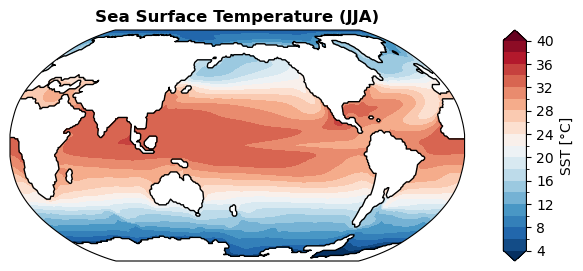

In [12]:
fig, ax = SST_JJA['mle'].x.plot(
    levels=np.linspace(4, 40, 19),
    cbar_kwargs={
        'ticks': np.linspace(4, 40, 10),
        'label': 'SST [°C]',
    },
)

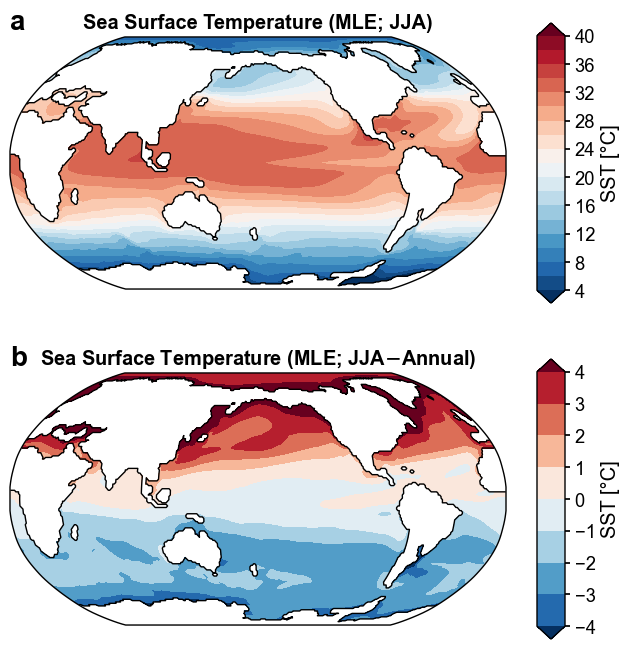

Figure saved at: "../figs/SIFig.04.pdf"


In [16]:
x4c.set_style('journal_spines', font_scale=1.2)
fig, ax = x4c.visual.subplots(
    figsize=(8, 8),
    nrow=2, ncol=1,
    hspace=0.2, wspace=0.1,
    ax_loc={
        'SST_JJA': (0, 0),
        'SST_diff': (1, 0),
    },
    projs={
        'SST_JJA': 'Robinson',
        'SST_diff': 'Robinson',
    },
    projs_kws={
        'SST_JJA': {'central_longitude': 180},
        'SST_diff': {'central_longitude': 180},
    },
    annotation=True,
    annotation_separate=True,
    annotation_kws={
        'SST_JJA': {'loc_x': 0., 'style': ''},
        'SST_diff': {'loc_x': 0., 'style': ''},
    },
)


SST_JJA['mle'].x.plot(
    ax=ax['SST_JJA'],
    levels=np.linspace(4, 40, 19),
    cbar_kwargs={
        'ticks': np.linspace(4, 40, 10),
        'label': 'SST [°C]',
    },
    title='Sea Surface Temperature (MLE; JJA)',
)

(SST_JJA['mle']-SST['mle']).x.plot(
    ax=ax['SST_diff'],
    levels=np.linspace(-4, 4, 9),
    cbar_kwargs={
        'ticks': np.linspace(-4, 4, 9),
        'label': 'SST [°C]',
    },
    cmap='RdBu_r',
    title='Sea Surface Temperature (MLE; JJA$-$Annual)',
)

x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.04.pdf')